# Module 7 Practical Exercises

This practical's notes contain the instruction of deep neural networks and recurrent neural networks using the Pytorch machine learning framework.

For deep neural networks, we will reuse the Veteran dataset from previous practicals, and compare the performance of a deep network with the single hidden layer network.

For recurrent neural networks, we will utilize long short-term memory cells to predict the maximum temperature for the next multiple timestep in various locations of Australia, given the observations from the last few days.

## Preparing Data
---

Use the same code from previous module to load/pre-process the Veteran dataset, and split it into the training/testing set.

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# read the veteran dataset
df = pd.read_csv('veteran.csv')

# Change DemCluster from interval/integer to nominal/str.
# Pandas returns a copy of the data whenever you access a column, therefore we need to store it back to the original column.
#print(df['DemCluster'])
df['DemCluster'] = df['DemCluster'].astype(str)

# Change DemHomeOwner into binary 0/1 variable.
dem_home_owner_map = {'U':0, 'H': 1}
df['DemHomeOwner'] = df['DemHomeOwner'].map(dem_home_owner_map)

# Set DemMedIncome to NaN for any values that are less than 1, which we will fix up below.
mask = df['DemMedIncome'] < 1
df.loc[mask, 'DemMedIncome'] = np.nan

# Fill missing/NaN values with the mean value across the columns.
df['DemAge'] = df['DemAge'].fillna(df['DemAge'].mean())
df['DemMedIncome'] = df['DemMedIncome'].fillna(df['DemMedIncome'].mean())
df['GiftAvgCard36'] = df['GiftAvgCard36'].fillna(df['GiftAvgCard36'].mean())

# drop ID and the unused target variable
df.drop(['ID', 'TargetD'], axis=1, inplace=True)

# one-hot encoding
df = pd.get_dummies(df)

# Obtain a list of labels (targets) for each of the samples. We refer to this as 'y'.
Y = df["TargetB"]

# Remove the label (target) from the samples, as this is not a feature that we want to use to predict against.
X = df.drop(['TargetB'], axis=1)

# Create a 30% train/test split from our samples.
# We set the random_state to the constant 10 to ensure it is the same from run-to-run.
# We set the stratisfy parameter to the labels, that way we get an even selection of 0 and 1 values in our testing set.
# Otherwise, we may end up with unbalanced 0/1 labels across the two splits.
# We use X.values to get arrays for the features, instead of a DataFrame with column names etc.
random_state = 10
test_set_size = 0.3 # 30%
X_train, X_test, y_train, y_test = train_test_split(X.values, Y.values, test_size=test_set_size, stratify=Y, random_state=random_state)

print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

random_seed = 10

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train, y_train)
X_test = scaler.transform(X_test)

Size of training set: 6780
Size of testing set: 2906


## Deep Neural Networks
---

The first task of this practical exercise is to extend the multi-layer perceptron neural network to a greater number of layers, creating a deep neural deep network. The "deep" aspect refers to having many hidden layers between input and output, allowing these systems to automatically discover intricate relationships within data without explicit programming of rules.

You will need Pytorch installed and configured for this practical, refer to previous modules for instructions on how to install Pytorch.

First, we will convert the training and test datasets into `torch.tensor`, making them compatible with Pytorch.

In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score
 
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

Next, we will define the network itself.

Pytorch contains the `Sequential` class, which provides a simplified way to build neural networks by arranging layers in a linear sequence, where the output of one layer serves as the input to the next. This container allows developers to define a network's architecture as an ordered list of modules that are automatically connected in sequence, eliminating the need to manually specify how data flows between components.

In [3]:
num_features = X_train.shape[1]
hidden_layer_size = 25
output_size = 1
n_epochs = 100
lr = 0.001
# define the model
model = nn.Sequential(
    nn.Linear(num_features, hidden_layer_size),
    nn.Linear(hidden_layer_size, output_size),
    nn.Sigmoid()
)
print(model)

Sequential(
  (0): Linear(in_features=85, out_features=25, bias=True)
  (1): Linear(in_features=25, out_features=1, bias=True)
  (2): Sigmoid()
)


You will notice that we are explicitly passing the data from one layer to the next, after applying the activation function. The `first` layer is followed by the ReLU activation function, followed by the `second` layer, which maps the hidden layer to the output size, which in this case is a single numerical value.

For our deep neural network, we will use the `Sequential` class. The straightforward syntax makes it particularly useful for quickly prototyping linear network structures, though more complex architectures with branching or skip connections would require custom Module implementations instead.

Let's start by defining a deep network with 5 hidden layers. Each of these hidden layers is represented by a `Linear` class in Pytorch, and we apply the ReLU activation function after each of them. We will use the same size for each of the hidden layers, but this is not required.

In [4]:
num_features = X_train.shape[1]
print(num_features)
hidden_layer_size = 25
output_size = 1      
in_features = num_features
# define the deep model
deep_model = nn.Sequential(
            nn.Linear(in_features, hidden_layer_size), # Input layer -> First Hidden Layer
            nn.ReLU(), # Activation Function
            nn.Linear(hidden_layer_size, hidden_layer_size), # First Hidden Layer -> Second Hidden Layer
            nn.ReLU(), # Activation Function
            nn.Linear(hidden_layer_size, hidden_layer_size), # Second Hidden Layer -> Third Hidden Layer
            nn.ReLU(), # Activation Function
            nn.Linear(hidden_layer_size, hidden_layer_size), # Third Hidden Layer -> Fourth Hidden Layer
            nn.ReLU(), # Activation Function
            nn.Linear(hidden_layer_size, output_size), # Fourth Hidden Layer -> Output Layer
            nn.Sigmoid() # Activation Function
)
print(deep_model)

85
Sequential(
  (0): Linear(in_features=85, out_features=25, bias=True)
  (1): ReLU()
  (2): Linear(in_features=25, out_features=25, bias=True)
  (3): ReLU()
  (4): Linear(in_features=25, out_features=25, bias=True)
  (5): ReLU()
  (6): Linear(in_features=25, out_features=25, bias=True)
  (7): ReLU()
  (8): Linear(in_features=25, out_features=1, bias=True)
  (9): Sigmoid()
)


Now we can train and evaluate both networks by passing them into `train_predict_model` function.

In [5]:
def train_predict_model(model, n_epochs, lr, X_train, y_train, X_test, y_test):
    # train the model
    loss_fn   = nn.BCELoss()  # binary cross entropy
    optimizer = optim.Adam(model.parameters(), lr=lr)
    count = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"The model has {count:,} trainable parameters")
    
    train_acc_history = []
    test_acc_history = []
    for i in range(n_epochs):
        y_pred = model(X_train)
        loss = loss_fn(y_pred, y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step() 
        with torch.no_grad():
            train_pred = model(X_train)
            train_pred = (train_pred >= 0.5).float()
            train_acc = accuracy_score(y_train, train_pred)
            test_pred = model(X_test)
            test_pred = (test_pred >= 0.5).float()
            test_acc = accuracy_score(y_test, test_pred)
        if (i % 1) == 0:
            print(f"Epoch {i+1}: Train Accuracy: {train_acc} Test Accuracy: {test_acc}")
        train_acc_history.append(train_acc)
        test_acc_history.append(test_acc)
    return train_acc_history, test_acc_history

In [6]:
model_train_acc, model_test_acc = train_predict_model(model, n_epochs, lr,X_train, y_train, X_test, y_test)
deep_model_train_acc, deep_model_test_acc = train_predict_model(deep_model, n_epochs, lr,X_train, y_train, X_test, y_test)

The model has 2,176 trainable parameters
Epoch 1: Train Accuracy: 0.4957227138643068 Test Accuracy: 0.5017205781142464
Epoch 2: Train Accuracy: 0.4989675516224189 Test Accuracy: 0.5044735030970406
Epoch 3: Train Accuracy: 0.5089970501474926 Test Accuracy: 0.5096352374397798
Epoch 4: Train Accuracy: 0.516519174041298 Test Accuracy: 0.5151410874053682
Epoch 5: Train Accuracy: 0.5228613569321534 Test Accuracy: 0.5178940123881625
Epoch 6: Train Accuracy: 0.5312684365781711 Test Accuracy: 0.522367515485203
Epoch 7: Train Accuracy: 0.5339233038348082 Test Accuracy: 0.5251204404679972
Epoch 8: Train Accuracy: 0.5383480825958702 Test Accuracy: 0.5282174810736407
Epoch 9: Train Accuracy: 0.541740412979351 Test Accuracy: 0.5323468685478321
Epoch 10: Train Accuracy: 0.5451327433628319 Test Accuracy: 0.5388850653819683
Epoch 11: Train Accuracy: 0.5486725663716814 Test Accuracy: 0.5426703372333104
Epoch 12: Train Accuracy: 0.5536873156342182 Test Accuracy: 0.5440467997247075
Epoch 13: Train Accurac

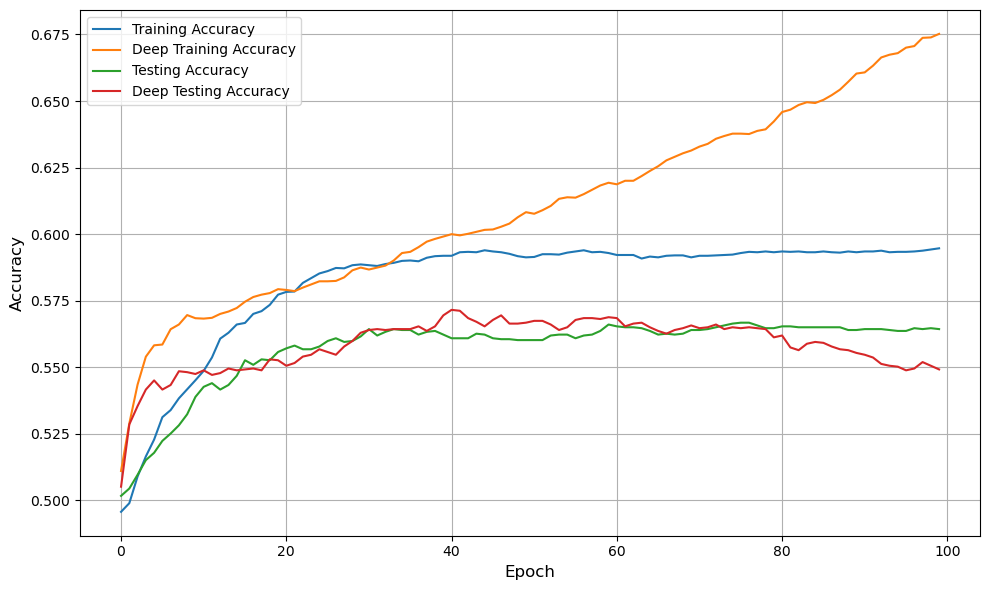

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.xlabel("Epoch", size=12)
plt.ylabel("Accuracy", size=12)
plt.plot(model_train_acc, label="Training Accuracy")
plt.plot(deep_model_train_acc, label="Deep Training Accuracy")
plt.plot(model_test_acc, label="Testing Accuracy")
plt.plot(deep_model_test_acc, label="Deep Testing Accuracy")
plt.grid()
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Comparing the parameter count, we can see that the shallow network has `~4,300` trainable parameters, whereas the deep network has `~12,000`. This suggests that the deep network has significantly more capacity for learning, which also risks overfitting.

We can see this overfitting by examining the plot above: the deep network achieved a much greater training accuracy of almost 90% after 100 epochs, compared to the shallow network which only reached ~65% accuracy after the same amount of time. However, this resulted in overfitting after around epoch #30, with the training accuracy continuing to increase, but the testing accuracy starting to drop.

Therefore, if we were deploying this model, we would want to cease training the network after around 30 epochs. Using early stopping would be one method for automatically stopping training after a number of consecutive epochs resulted in reduced testing accuracy, and roll back to the last "good" set of weights.

We can also observe that the deep network achieved slightly higher testing accuracy at its peak compared to the shallow network. At epoch #39, the accuracy of the deep network was around 56-57%, while the shallow network was 55-56%.

## Recurrent Neural Networks
---

In this module, we introduced the concept of recurrent nerual networks. Specifically, we introduced the long short-term memory (LSTM) neural network, which we will be demonstrating in this practical session.

Long Short-Term Memory (LSTM) networks are a specialized form of recurrent neural networks designed to overcome the vanishing gradient problem that hampers learning in traditional RNNs. By utilizing a gating mechanism that consists of input, forget and output gates, LSTMs can selectively remember or discard information, allowing them to capture long-range dependencies in sequential data. Each LSTM cell maintains a cell state that acts as a conveyor belt of information flowing through the sequence, with gates controlling what information is added, removed, or passed to the output.

LSTMs have a range of applications, including natural language processing, speech recognition, time series prediction, and any domain where contextual information across varying time scales is crucial for accurate predictions. In this practical, we will be exploring time series prediction using LSTMs. While the implementation details for other applications will differ, the high-level approach is the same.

### Dataset for our LSTM network

In this practical, we will use a subset of Australian weather data that contains observations from many locations across Australia, including the minimum/maximum temperature, rainfall, wind, humidity, and pressure. The dataset was preprocessed and contains ~10,000 rows from different cities, and the following columns:

- Location - Name of the city from Australia.
- MinTemp - The Minimum temperature during a particular day. (degree Celsius)
- MaxTemp - The maximum temperature during a particular day. (degree Celsius)
- Rainfall - Rainfall during a particular day. (millimeters)
- WindGuSpeed - Speed of strongest gust during a particular day. (kilometers per hour)
- WindSpeed9am - Speed of the wind for 10 min prior to 9 am. (kilometers per hour)
- WindSpeed3pm - Speed of the wind for 10 min prior to 3 pm. (kilometers per hour)
- Humidity9am - The humidity of the wind at 9 am. (percent)
- Humidity3pm - The humidity of the wind at 3 pm. (percent)
- Pressure9am - Atmospheric pressure at 9 am. (hectopascals)
- Pressure3pm - Atmospheric pressure at 3 pm. (hectopascals)
- Temp9am - The temperature at 9 am. (degree Celsius)
- Temp3pm - The temperature at 3 pm. (degree Celsius)

This raw dataset and information was obtained from Kaggle: https://www.kaggle.com/datasets/arunavakrchakraborty/australia-weather-data

The observations in the dataset itself were sourced from the Bureau of Meteorology, and collated by Arunava Kr. Chakraborty.

In [8]:
df = pd.read_csv("weather.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99516 entries, 0 to 99515
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   row ID         99516 non-null  object 
 1   Location       99516 non-null  object 
 2   MinTemp        99073 non-null  float64
 3   MaxTemp        99286 non-null  float64
 4   Rainfall       98537 non-null  float64
 5   Evaporation    56985 non-null  float64
 6   Sunshine       52199 non-null  float64
 7   WindGustDir    92995 non-null  object 
 8   WindGustSpeed  93036 non-null  float64
 9   WindDir9am     92510 non-null  object 
 10  WindDir3pm     96868 non-null  object 
 11  WindSpeed9am   98581 non-null  float64
 12  WindSpeed3pm   97681 non-null  float64
 13  Humidity9am    98283 non-null  float64
 14  Humidity3pm    97010 non-null  float64
 15  Pressure9am    89768 non-null  float64
 16  Pressure3pm    89780 non-null  float64
 17  Cloud9am       61944 non-null  float64
 18  Cloud3

In [9]:
df.drop(columns=['Evaporation', 'Sunshine','Cloud9am', 'Cloud3pm','RainTomorrow'], inplace=True)
# Remove invalid rows.
df = df.dropna()
df

,row ID,Location,MinTemp,MaxTemp,Rainfall,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm,RainToday
0,Row0,Albury,13.4,22.9,0.6,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,16.9,21.8,No
1,Row1,Albury,7.4,25.1,0.0,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,17.2,24.3,No
2,Row2,Albury,17.5,32.3,1.0,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,17.8,29.7,No
3,Row3,Albury,14.6,29.7,0.2,WNW,56.0,W,W,19.0,24.0,55.0,23.0,1009.2,1005.4,20.6,28.9,No
4,Row4,Albury,7.7,26.7,0.0,W,35.0,SSE,W,6.0,17.0,48.0,19.0,1013.4,1010.1,16.3,25.5,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99511,Row101816,Uluru,8.0,20.7,0.0,ESE,41.0,SE,E,19.0,26.0,56.0,32.0,1028.1,1024.3,11.6,20.0,No
99512,Row101817,Uluru,3.5,21.8,0.0,E,31.0,ESE,E,15.0,13.0,59.0,27.0,1024.7,1021.2,9.4,20.9,No
99513,Row101818,Uluru,2.8,23.4,0.0,E,31.0,SE,ENE,13.0,11.0,51.0,24.0,1024.6,1020.3,10.1,22.4,No
99514,Row101819,Uluru,3.6,25.3,0.0,NNW,22.0,SE,N,13.0,9.0,56.0,21.0,1023.5,1019.1,10.9,24.5,No


In [10]:
# Sort for consistent grouping
samples_sorted = df.sort_values(['Location']).copy()

# Create a 10-day group id per location
samples_sorted['day_index'] = samples_sorted.groupby('Location').cumcount()
samples_sorted['ten_day_group'] = samples_sorted['day_index'] // 20

# Group by Location and 10-day group and take the mean of numeric columns
ten_day_avg = samples_sorted.groupby(['Location', 'ten_day_group']).mean(numeric_only=True).reset_index()

# Optional: drop intermediate columns
ten_day_avg = ten_day_avg.drop(columns=['day_index', 'ten_day_group'], errors='ignore')

# Preview
print(ten_day_avg.head())

   Location  MinTemp  MaxTemp  Rainfall  WindGustSpeed  WindSpeed9am  \
0  Adelaide    7.950   17.465      0.95          36.05         10.30   
1  Adelaide    9.185   19.105      1.50          36.85         11.30   
2  Adelaide   10.455   21.415      0.56          37.85         13.75   
3  Adelaide   11.070   20.670      2.98          34.25         10.70   
4  Adelaide   10.935   18.565      2.56          38.30         11.80   

   WindSpeed3pm  Humidity9am  Humidity3pm  Pressure9am  Pressure3pm  Temp9am  \
0         14.85        57.80        45.65     1027.635     1025.565   12.810   
1         16.65        63.40        50.15     1021.140     1019.075   14.045   
2         16.45        51.00        39.10     1022.005     1018.895   16.235   
3         14.75        66.15        48.95     1019.935     1017.735   15.540   
4         16.65        73.05        55.60     1019.805     1017.770   14.210   

   Temp3pm  
0   16.350  
1   17.705  
2   20.335  
3   19.835  
4   17.730  


In [11]:
ten_day_avg

,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
0,Adelaide,7.950,17.465,0.95,36.05,10.30,14.85,57.80,45.65,1027.635,1025.565,12.810,16.350
1,Adelaide,9.185,19.105,1.50,36.85,11.30,16.65,63.40,50.15,1021.140,1019.075,14.045,17.705
2,Adelaide,10.455,21.415,0.56,37.85,13.75,16.45,51.00,39.10,1022.005,1018.895,16.235,20.335
3,Adelaide,11.070,20.670,2.98,34.25,10.70,14.75,66.15,48.95,1019.935,1017.735,15.540,19.835
4,Adelaide,10.935,18.565,2.56,38.30,11.80,16.65,73.05,55.60,1019.805,1017.770,14.210,17.730
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3972,Woomera,19.465,32.030,2.06,48.40,22.25,23.65,58.50,32.05,1011.470,1009.600,22.725,30.235
3973,Woomera,18.540,31.580,2.03,57.20,24.50,25.45,47.10,26.25,1010.665,1008.545,22.605,29.430
3974,Woomera,11.115,24.545,0.71,47.45,23.90,23.40,51.00,25.85,1017.350,1014.740,16.215,23.095
3975,Woomera,14.650,29.455,0.13,47.40,22.35,23.15,43.50,26.95,1018.290,1015.260,20.445,27.890


In [12]:
ten_day_avg['Location'].unique().tolist()

['Adelaide',
 'Albury',
 'AliceSprings',
 'BadgerysCreek',
 'Ballarat',
 'Bendigo',
 'Brisbane',
 'Cairns',
 'Canberra',
 'Cobar',
 'CoffsHarbour',
 'Dartmoor',
 'Darwin',
 'GoldCoast',
 'Hobart',
 'Katherine',
 'Launceston',
 'Melbourne',
 'MelbourneAirport',
 'Mildura',
 'Moree',
 'MountGambier',
 'Nhil',
 'NorahHead',
 'NorfolkIsland',
 'Nuriootpa',
 'PearceRAAF',
 'Perth',
 'PerthAirport',
 'Portland',
 'Richmond',
 'Sale',
 'Sydney',
 'SydneyAirport',
 'Townsville',
 'Tuggeranong',
 'Uluru',
 'WaggaWagga',
 'Walpole',
 'Watsonia',
 'Williamtown',
 'Witchcliffe',
 'Wollongong',
 'Woomera']

In [13]:
ten_day_avg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3977 entries, 0 to 3976
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       3977 non-null   object 
 1   MinTemp        3977 non-null   float64
 2   MaxTemp        3977 non-null   float64
 3   Rainfall       3977 non-null   float64
 4   WindGustSpeed  3977 non-null   float64
 5   WindSpeed9am   3977 non-null   float64
 6   WindSpeed3pm   3977 non-null   float64
 7   Humidity9am    3977 non-null   float64
 8   Humidity3pm    3977 non-null   float64
 9   Pressure9am    3977 non-null   float64
 10  Pressure3pm    3977 non-null   float64
 11  Temp9am        3977 non-null   float64
 12  Temp3pm        3977 non-null   float64
dtypes: float64(12), object(1)
memory usage: 404.0+ KB


In [14]:
import pandas as pd

# Step 1: Count the number of time steps per location
location_counts = ten_day_avg['Location'].value_counts()

# Step 2: Identify locations with at least 141 time steps
valid_locations = location_counts[location_counts >= 64].index

# Step 3: Filter to keep only valid locations
df_valid = ten_day_avg[ten_day_avg['Location'].isin(valid_locations)].copy()

# Step 4: Trim each location to the first 141 rows
df_trimmed = (
    df_valid.groupby('Location', group_keys=False)
    .apply(lambda x: x.iloc[:64])
    .reset_index(drop=True)
)

# Optional: Confirm result
print(df_trimmed['Location'].value_counts())
print("Total locations kept:", df_trimmed['Location'].nunique())


Location
Adelaide            64
Albury              64
AliceSprings        64
BadgerysCreek       64
Ballarat            64
Bendigo             64
Brisbane            64
Cairns              64
Canberra            64
Cobar               64
CoffsHarbour        64
Dartmoor            64
Darwin              64
GoldCoast           64
Hobart              64
Melbourne           64
MelbourneAirport    64
Mildura             64
Moree               64
MountGambier        64
NorahHead           64
NorfolkIsland       64
Nuriootpa           64
PearceRAAF          64
Perth               64
PerthAirport        64
Portland            64
Richmond            64
Sale                64
Sydney              64
SydneyAirport       64
Townsville          64
Tuggeranong         64
WaggaWagga          64
Walpole             64
Watsonia            64
Williamtown         64
Witchcliffe         64
Wollongong          64
Woomera             64
Name: count, dtype: int64
Total locations kept: 40


/tmp/ipykernel_1675490/733456846.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.iloc[:64])


In [15]:
df_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2560 entries, 0 to 2559
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2560 non-null   object 
 1   MinTemp        2560 non-null   float64
 2   MaxTemp        2560 non-null   float64
 3   Rainfall       2560 non-null   float64
 4   WindGustSpeed  2560 non-null   float64
 5   WindSpeed9am   2560 non-null   float64
 6   WindSpeed3pm   2560 non-null   float64
 7   Humidity9am    2560 non-null   float64
 8   Humidity3pm    2560 non-null   float64
 9   Pressure9am    2560 non-null   float64
 10  Pressure3pm    2560 non-null   float64
 11  Temp9am        2560 non-null   float64
 12  Temp3pm        2560 non-null   float64
dtypes: float64(12), object(1)
memory usage: 260.1+ KB


In [16]:
# Filter to only observations from a list of locations.
#locations = ['Brisbane', 'Melbourne', 'Sydney']  # your list of locations
#locations = ['Brisbane']  # your list of locations
locations = df_trimmed['Location'].unique().tolist()
samples = df_trimmed[df_trimmed['Location'].isin(locations)]

# Remove invalid rows.
samples = samples.dropna()

# Show information about the data.
print(samples.info())
samples.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2560 entries, 0 to 2559
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Location       2560 non-null   object 
 1   MinTemp        2560 non-null   float64
 2   MaxTemp        2560 non-null   float64
 3   Rainfall       2560 non-null   float64
 4   WindGustSpeed  2560 non-null   float64
 5   WindSpeed9am   2560 non-null   float64
 6   WindSpeed3pm   2560 non-null   float64
 7   Humidity9am    2560 non-null   float64
 8   Humidity3pm    2560 non-null   float64
 9   Pressure9am    2560 non-null   float64
 10  Pressure3pm    2560 non-null   float64
 11  Temp9am        2560 non-null   float64
 12  Temp3pm        2560 non-null   float64
dtypes: float64(12), object(1)
memory usage: 260.1+ KB
None


,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
count,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000,2560.000000
mean,12.607527,23.487586,2.432283,40.745137,15.147949,19.465879,67.924609,51.205000,1017.546020,1015.196566,17.373400,21.956949
std,5.053111,5.383574,2.858874,5.898471,4.239553,4.218447,11.898093,13.724794,3.597303,3.657229,5.181917,5.227467
min,-0.675000,9.680000,0.000000,21.550000,3.900000,7.650000,13.350000,8.450000,1006.025000,1003.120000,5.380000,8.865000
25%,8.865000,19.503750,0.670000,36.950000,12.150000,16.437500,61.450000,42.550000,1015.097500,1012.782500,13.560000,18.121250
50%,12.102500,23.237500,1.580000,40.700000,15.100000,19.400000,69.150000,52.600000,1017.565000,1015.355000,16.992500,21.657500
75%,16.250000,27.442500,3.130000,44.550000,17.950000,22.450000,75.950000,61.312500,1020.100000,1017.795000,21.002500,25.695000
max,25.640000,39.810000,37.440000,63.850000,28.250000,32.250000,97.650000,83.750000,1030.135000,1027.850000,30.115000,37.895000


In [17]:
samples

,Location,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Temp9am,Temp3pm
0,Adelaide,7.950,17.465,0.95,36.05,10.30,14.85,57.80,45.65,1027.635,1025.565,12.810,16.350
1,Adelaide,9.185,19.105,1.50,36.85,11.30,16.65,63.40,50.15,1021.140,1019.075,14.045,17.705
2,Adelaide,10.455,21.415,0.56,37.85,13.75,16.45,51.00,39.10,1022.005,1018.895,16.235,20.335
3,Adelaide,11.070,20.670,2.98,34.25,10.70,14.75,66.15,48.95,1019.935,1017.735,15.540,19.835
4,Adelaide,10.935,18.565,2.56,38.30,11.80,16.65,73.05,55.60,1019.805,1017.770,14.210,17.730
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2555,Woomera,5.465,16.585,0.57,36.50,10.85,18.20,76.10,37.95,1025.280,1022.905,9.510,15.825
2556,Woomera,9.100,20.750,0.18,43.65,18.80,20.65,61.80,36.80,1021.685,1018.690,14.220,19.235
2557,Woomera,10.450,21.885,2.30,42.20,16.85,21.40,64.15,37.05,1018.685,1016.135,14.865,20.995
2558,Woomera,11.860,24.495,0.01,36.25,16.20,14.80,58.95,30.80,1022.075,1019.355,16.505,23.390


In [18]:
samples.to_csv('weather_data.csv', index=False)

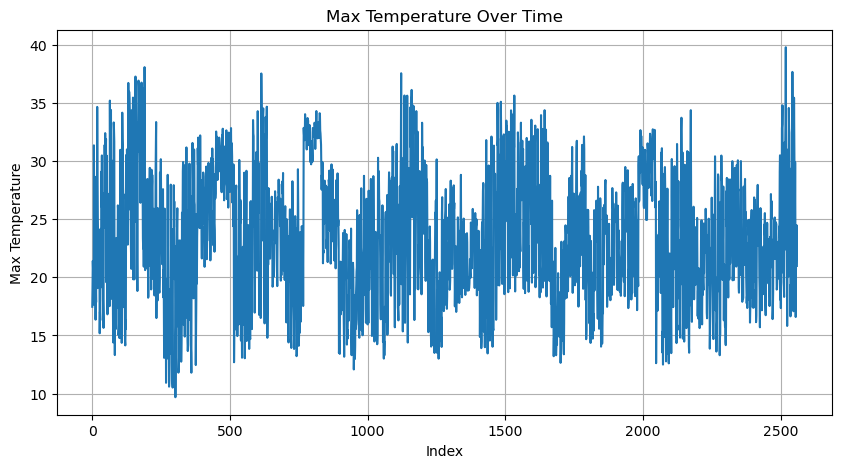

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(samples['MaxTemp'])
plt.title('Max Temperature Over Time')
plt.xlabel('Index')
plt.ylabel('Max Temperature')
plt.grid(True)
plt.show()


In [20]:
print(samples['Location'].value_counts())

Location
Adelaide            64
Albury              64
AliceSprings        64
BadgerysCreek       64
Ballarat            64
Bendigo             64
Brisbane            64
Cairns              64
Canberra            64
Cobar               64
CoffsHarbour        64
Dartmoor            64
Darwin              64
GoldCoast           64
Hobart              64
Melbourne           64
MelbourneAirport    64
Mildura             64
Moree               64
MountGambier        64
NorahHead           64
NorfolkIsland       64
Nuriootpa           64
PearceRAAF          64
Perth               64
PerthAirport        64
Portland            64
Richmond            64
Sale                64
Sydney              64
SydneyAirport       64
Townsville          64
Tuggeranong         64
WaggaWagga          64
Walpole             64
Watsonia            64
Williamtown         64
Witchcliffe         64
Wollongong          64
Woomera             64
Name: count, dtype: int64


In [21]:
samples.columns

Index(['Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm'],
      dtype='object')

## Univariate Forecasting
---

Next, we need to select the features that we are going to use as inputs for our weather forecast. Whether we select a single feature, or multiple features will determine whether the model is a univariate or multivariate LSTM.

Univariate LSTMs process a single time-dependent variable, such as daily stock prices or temperature readings, focusing on temporal patterns within that single feature to predict future values of the same variable. In contrast, multivariate LSTMs handle multiple interrelated variables simultaneously, such as temperature, humidity, wind speed, and pressure for weather forecasting, allowing the model to capture not only temporal dependencies but also complex relationships between different features over time.

To begin with, we will start with a simple, univariate model. We will use the historical (`MaxTemp`) as the time-dependent variable, and predict the maximum temperature for the day (`MaxTemp`). Extract this feature into the corresponding X/y values as we have done in previous practicals.

### Creating Sequences for Forecasting Multiple Data Points
---

We cannot simply feed the input data into the network in its original row-based form as we have done with other network architectures. Since we are predicting the "next" multipe time series value based on previous observations, we need to first transform the data into a "sequence", where each element in the sequence represents the attribute at that given point in time.

This is also known as sequence-to-sequence prediction. Sequence-to-sequence is a more challenging problem, as we have to forecast a greater number of data points with the same amount of input data, compared to predicting one value at a time, where you have another time step worth of features.

To do so, we are going to define a function named `create_sequences()`. This function should take our input data, the target values, and a sequence length as parameters. Our input is going to be of dimension $ N \times T \times F $, and create an output of $ N \times P $, where $ N $ represents the number of samples, $ T $ represents the number of time points to lookback in the past, $ F $ represents the number of features, and $ P $ represents the number of future time points (forecast horizon) that we are predicting.

Note that all sequences are padded to the same length, which ensures that the model can efficiently handle inputs of varying original lenghts while maintaining consistent input dimensions. 

In [23]:
def create_sequences(sequence, lookback, forecast_horizon, target_col):
    T, num_features = sequence.shape
    print ("T", T, "num_features", num_features)
    X, y, lengths = [], [], []
    pad_vector = np.zeros((lookback, num_features))

        # Fixed-length lookback with pre-padding
    for t in range(1, T - forecast_horizon + 1):
        context = sequence[:t]
        if len(context) > lookback:
            context = context[-lookback:]

        padded_context = pad_vector.copy()
        padded_context[-len(context):] = context

        X.append(padded_context)
        y.append(sequence[t:t + forecast_horizon, target_col])
        lengths.append(min(len(context), lookback))

    return np.array(X), np.array(y), lengths

The `data_prep` processes each location separately, splitting the data into training and testing sets, where the last `test_steps` are reserved for testing. We will standardize the feature by removing the mean and scaling to unit variance with the scikit-learn `StandardScaler` class. Normalizing the data will improve the performance of our LSTM model.The sequences created using `create_sequences()` are collected across all locations and concatenated into arrays suitable for LSTM input. Storing the `train_sample` and `test_sample` will allow us to evaluate the model.

In [25]:
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler

def data_prep(df, feature_columns, lookback, test_steps, target_col):
    # Prepare to store all training data
    X_all, y_all = [], []
    location_ids = []  # To track which location each sample comes from
    test_data = []  # To store test data for each location
    train_data = []
    lengths_all = []  # To store the lengths of each sequence for packing

    # Process each location's data
    for location_id, group in df.groupby('Location'):
        feature_values = group[feature_columns].values

        # If there are not enough samples for training, skip this location
        if len(feature_values) <= 63:
            continue
            
        # Separate the last 12 steps for testing
        # Scale the data
        scaler = StandardScaler()
        train_sample = scaler.fit_transform(feature_values[:-test_steps])
        test_sample = scaler.transform(feature_values[-test_steps:])
        
        # If you prefer without scaling
        #train_sample = feature_values[:-test_steps]
        #test_sample = feature_values[-test_steps:]
        
        train_data.append((location_id, train_sample))
        test_data.append((location_id, test_sample, scaler))  # Store test data and scaler

        # Prepare LSTM sequence data for training
        X_location, y_location, lengths = create_sequences(train_sample, lookback, test_steps, target_col)

        # Append to the overall dataset
        X_all.append(X_location)
        y_all.append(y_location)
        lengths_all.append(lengths)  # Store sequence lengths

        # Store Location ID for tracking
        location_ids.extend([location_id] * len(y_location))

    # Concatenate all locations' training data for model training
    X_all = np.concatenate(X_all, axis=0)
    y_all = np.concatenate(y_all, axis=0)
    lengths_all = np.concatenate(lengths_all, axis=0)  # Concatenate sequence lengths

    # Reshape X to be [samples, time steps, features] as required by LSTM
    X_all = X_all.reshape((X_all.shape[0], X_all.shape[1], X_all.shape[2]))  
    
    return torch.Tensor(X_all), torch.Tensor(y_all), torch.Tensor(lengths_all), train_data, test_data


We can then use this function to create our sequences for the `MaxTemp` data, and split it into the training/testing set as we have done in previous practicals. For this demonstration, we will use 5 time points in the past (`lookback`) to predict 5 time points in the future (`test_steps`). The `target_col` refers to the index of the target attribute for prediction. As this is a univariate model, the value `0` will represent the input as well as target.

In [26]:
lookback = 5
test_steps = 5
target_col = 0
X_5, y_5, lenghts_5, train_d_5, test_d_5 = data_prep(samples,['MaxTemp'],lookback,test_steps, target_col)

print("Shape of input data after sequence creation:", X_5.shape)
print("Shape of targets after sequence creation:", y_5.shape)

T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
T 59 num_features 1
Shape of input data after sequence creation: torch.Size([2160, 5, 1])
Shape of targets after sequence creation: torch.Size([2160, 5])


## Defining the LSTM network
---

Pytorch includes the implementation of the long short-term memory layer in the `LSTM` class in the `nn` module. We can utilize this class in a new `nn.Module` network. Unlike the `Linear` class where we only had to define an input and output size, the `LSTM` class requires more parameters to be defined. These include:

- `input_size`: The number of features that are input into this layer.
- `hidden_size`: The number of features in the hidden layer. This also corresponds to the output size of the LSTM layer.
- `num_layers`: The number of recurrent stacked recurrent layers.
- `batch_first`: This parameter allows the input to be provided in the form of $ N \times T \times F $. If we did not set `batch_first`, we would have to reverse the input tensor order, and provide the data in the form of $ T \times N \times F $.

After the LSTM layer, we need to map the intermediate features to our output variable, which is a sequence of numerical values. Note that since we are predicting numerical values rather than a probability, we do not use an activation function on the output of the linear/mapping layer.

In [27]:
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

class MyLSTMNet(nn.Module):
    def __init__(self, num_features, hidden_layer_size, num_layers, output_size, dropout_prob):
        super().__init__()
        self.lstm = nn.LSTM(input_size=num_features,  
                            hidden_size=hidden_layer_size,
                            num_layers=num_layers,
                            batch_first=True)
        self.dropout = nn.Dropout(dropout_prob)
        self.fc = nn.Linear(hidden_layer_size, output_size) # fully connected layer

    def forward(self, data, lengths):
        # Pack the input sequence - This ensures that the LSTM ignores padded values during computation.
        packed_data = pack_padded_sequence(data, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # Run through LSTM
        packed_output, (hn, cn) = self.lstm(packed_data)

        # Use the last layer's hidden state
        last_hidden = hn[-1]  

        # Apply dropout and final linear layer
        out = self.dropout(last_hidden)
        out = self.fc(out)  
        return out


Let us now initialize the necessary parameters for our LSTM model. 

In [28]:
num_features = X_5.shape[2]
hidden_layer_size = 10
output_size = test_steps
num_layers = 2
dropout_prob = 0.2
model_lstm_5 = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)

In [29]:
print(model_lstm_5)

MyLSTMNet(
  (lstm): LSTM(1, 10, num_layers=2, batch_first=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=10, out_features=5, bias=True)
)


### Defining the Training Process
---

As we are working with time series data, and predicting a numeric value rather than a class, we cannot use the previous `train_predict_model` function directly. Instead, we have to make a number of changes:

- Instead of computing accuracy, we will compute loss.
- Instead of using binary cross entropy as a loss function, we will use mean squared error. BCE loss only works on binary labels.
- Instead of displaying the loss after every epoch, we will only display it after every 100 epochs. Because of our selected dataset, the model will require significantly more epochs to train compared to the earlier neural networks we have worked with.
- Due to having a smaller number of samples, we will use a lower batch size to reduce the range of data that will affect the weights in one "pass". There is no "perfect" batch size, the choice will depend both on your network design and dataset.
- We will return model that has lowest validation as the best model for evaluation/future usage.

> ***Side note: Loss functions***
> 
> Loss functions serve as quantitative measures of model performance in machine learning by calculating the disparity between predicted and actual values, essentially guiding optimization algorithms toward better parameter configurations.

In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split

def train_predict_model(model, n_epochs, lr, X_all, y_all, lengths, validation_split=0.2):
    batch_size = 32

    # Split data into train and validation sets
    dataset = TensorDataset(X_all, y_all, lengths)
    val_size = int(len(dataset) * validation_split)
    train_size = len(dataset) - val_size
    train_set, val_set = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)

    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"The model has {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable parameters")

    train_loss_history = []
    val_loss_history = []

    best_val_loss = float('inf')
    best_model_state = None

    for epoch in range(n_epochs):
        model.train()
        for X_batch, y_batch, lengths_batch in train_loader:
            y_pred = model(X_batch, lengths_batch)
            loss = loss_fn(y_pred, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Validation check every 100 epochs
        if epoch % 100 == 0:
            model.eval()
            with torch.no_grad():
                train_preds = model(X_all[train_set.indices], lengths[train_set.indices])
                train_loss = loss_fn(train_preds, y_all[train_set.indices]).item()

                val_preds = model(X_all[val_set.indices], lengths[val_set.indices])
                val_loss = loss_fn(val_preds, y_all[val_set.indices]).item()

                print(f"Epoch {epoch+1}: train loss {train_loss:.4f}, val loss {val_loss:.4f}")

                train_loss_history.append(train_loss)
                val_loss_history.append(val_loss)

                # Save best model
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    best_model_state = model.state_dict()

    # Restore best model state
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return train_loss_history, val_loss_history, model


### Training the Univariate LSTM Model

We can now finally train our model. As mentioned above, we will need a significantly larger number of epochs for training this model compared to the others we have trained in this unit. Let's start with 500 epochs.

In [31]:
n_epochs = 501
lr = 0.001
train_loss_history_5,val_loss_history_5, model_lstm_5 = train_predict_model(model_lstm_5, n_epochs, 
                                                                            lr, X_5, y_5, lenghts_5,
                                                                            validation_split=0.2)

The model has 1,455 trainable parameters
Epoch 1: train loss 1.0086, val loss 1.0012
Epoch 101: train loss 0.8228, val loss 0.8650
Epoch 201: train loss 0.7869, val loss 0.8709
Epoch 301: train loss 0.7599, val loss 0.8720
Epoch 401: train loss 0.7378, val loss 0.8916
Epoch 501: train loss 0.7134, val loss 0.9014


As we did with the deep neural network, let's examine the performance across the training process by plotting epochs against loss. 

In [33]:
def vis_train_loss(train_loss_history, val_loss_history):
    epochs = range(0, n_epochs, 100) 
    plt.plot(epochs, train_loss_history, label='Training Loss')
    plt.plot(epochs, val_loss_history, label='Validation Loss')  # <-- add this line
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Loss Convergence')
    plt.legend()
    plt.grid()
    plt.show()

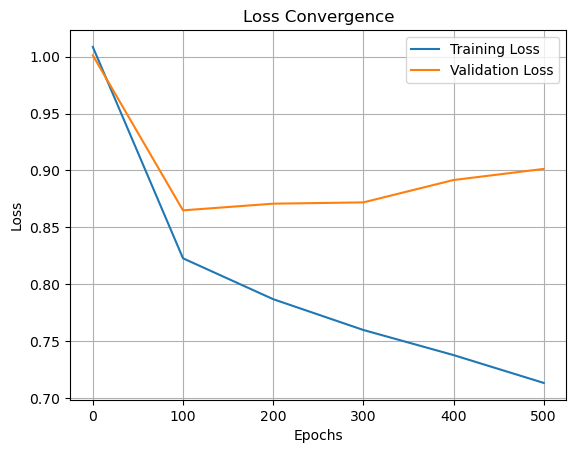

In [34]:
vis_train_loss(train_loss_history_5, val_loss_history_5)

We can observe that our training loss continued to decrease, but our testing loss started to increase above approximately 300. This would be another good place to utilize early stopping, but that is outside the scope of this practical document.

### Computing the RMSE
---

To compute the root mean square error of the model's predictions, we can simply use `root_mean_squared_error` from scikit-learn.

We can compute the $ R^2 $ score in a similar manner.

Let's also plot the predictions that the LSTM model has made and compare them to the labelled data.

In [36]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
def pred_eval(model, X, y, lengths, train_d, test_d, lookback, target_col):
    model.eval()
    with torch.no_grad():
        train_preds = model(X, lengths)
        print("Training RMSE:",root_mean_squared_error(y.flatten().tolist(),train_preds.flatten().tolist()))
        print("Training R2:", r2_score(y.flatten().tolist(),train_preds.flatten().tolist()))
        X_test = []
        y_test = []
        lengths_test = []
        for count, (location_id, test_values, scaler) in enumerate(test_d):
            train_values = train_d[count][1]
            X_test.append(train_values[-lookback:])
            y_test.append(test_values[:,target_col])
            # Append the actual lengths (just like the training phase)
            lengths_test.append(len(train_values[-lookback:]))  
        X_test = torch.Tensor(X_test) 
        y_test = torch.Tensor(y_test)
        lengths_test = torch.Tensor(lengths_test).long()
        test_preds = model(X_test,lengths_test)
        #print(y_test.flatten().tolist())
        #print(test_preds.flatten().tolist())
        print("Test RMSE:",root_mean_squared_error(y_test.flatten().tolist(),test_preds.flatten().tolist()))
        print("Test R2:", r2_score(y_test.flatten().tolist(),test_preds.flatten().tolist()))
        plt.figure(figsize=(10, 6))
        plt.plot(y_test.flatten().tolist(), label="Expected Value")
        plt.plot(test_preds.flatten().tolist(), label="Predicted Value")
        plt.grid()
        plt.legend(fontsize=10)
        plt.tight_layout()
        plt.show()

Training RMSE: 0.8665835208238576
Training R2: 0.24997465228152815
Test RMSE: 0.8674201158956493
Test R2: 0.18567977232341182


/tmp/ipykernel_1675490/3342588267.py:18: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /home/task_176302495411461/conda-bld/libtorch_1763025026769/work/torch/csrc/utils/tensor_new.cpp:254.)
  X_test = torch.Tensor(X_test)


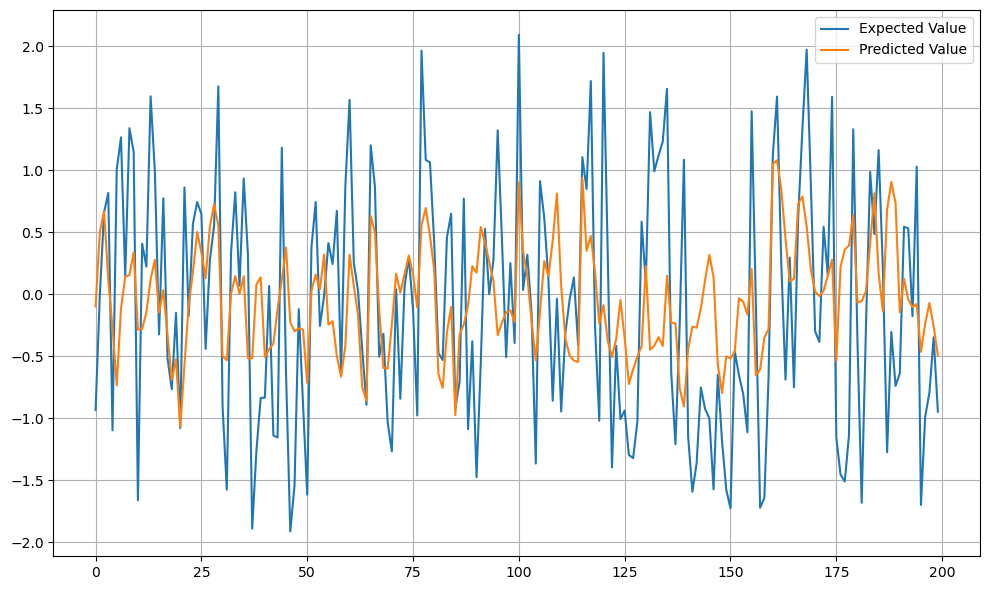

In [37]:
lookback = 5
target_col = 0
pred_eval(model_lstm_5, X_5, y_5, lenghts_5, train_d_5, test_d_5, lookback, target_col)

While we can see the general trend is being followed, it appears that our model is unable to predict many of the more extreme values. 

From this plot, we can come to a conclusion: the model is incapable of accurately predicting the extreme values, but on average predicts in the correct ballpark. This may be due to a number of reasons: the model architecture, the data, or the fact that we are only making a prediction based on a single variable: the historical `MaxTemp`.

## Multivariate LSTM model
---

Instead of only relying on the `MaxTemp`, let's utilize a larger number of the input features that we have available. Repeat the process from before by selecting the features, creating the sequence, and training the model. We do not need to change the architecture of the LSTM network, as we can simply provide a different number of input features to the constructor.

This gives us `12` features per time step. Now we can train the new model. Let us use the same `lookback` and `test_steps` values. 

Note that the `target_col` is set to `1` because our target attribute, `MaxTemp`, is located at index `1` in the list of `12` features included in the model.

T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
Shape of input data after sequence creation: torch.Size([2160, 5, 12])
Shape of targets after sequence creation: torch.Size([2160, 5])
The model has 1,895 train

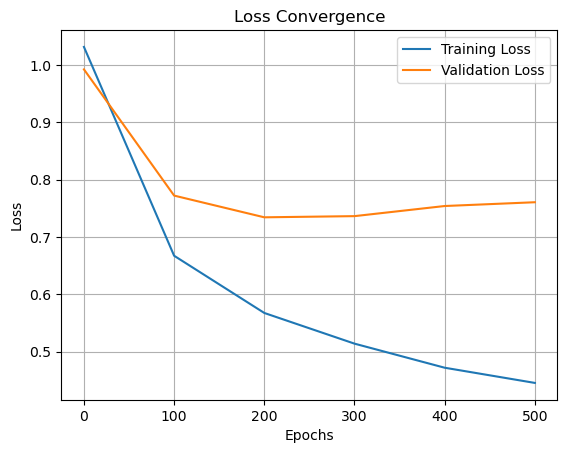

Training RMSE: 0.7129158358243184
Training R2: 0.4923883134567848
Test RMSE: 1.0637999324089162
Test R2: -0.22477457049758964


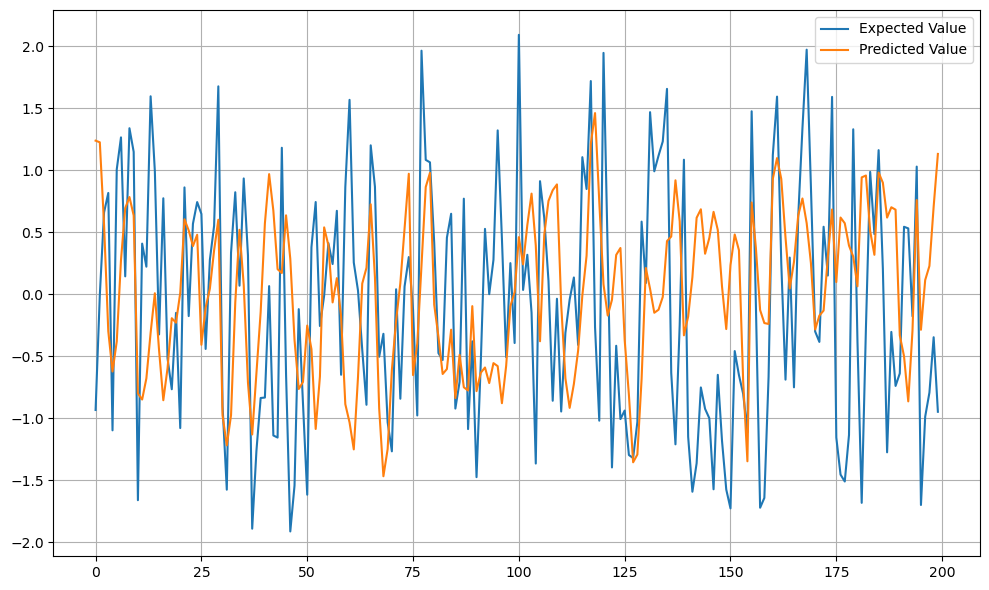

In [38]:
lookback = 5
test_steps = 5
target_col = 1
X_5_mv, y_5_mv, lenghts_5_mv, train_d_5_mv, test_d_5_mv = data_prep(samples,['MinTemp', 'MaxTemp', 
                                                                             'Rainfall', 'WindGustSpeed',
                                                                             'WindSpeed9am', 'WindSpeed3pm', 
                                                                             'Humidity9am', 'Humidity3pm',
                                                                             'Pressure9am', 'Pressure3pm', 
                                                                             'Temp9am', 'Temp3pm'],
                                                                    lookback,test_steps, target_col)

print("Shape of input data after sequence creation:", X_5_mv.shape)
print("Shape of targets after sequence creation:", y_5_mv.shape)

num_features = X_5_mv.shape[2]
hidden_layer_size = 10
output_size = test_steps
n_epochs = 501
lr = 0.001
num_layers = 2
dropout_prob = 0.2

model_lstm_5_mv = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)
train_loss_history_5_mv,val_loss_history_5_mv, model_lstm_5_mv = train_predict_model(model_lstm_5_mv, 
                                                                                     n_epochs, lr, X_5_mv, 
                                                                                     y_5_mv, lenghts_5_mv,
                                                                                     validation_split=0.2)
vis_train_loss(train_loss_history_5_mv, val_loss_history_5_mv)
pred_eval(model_lstm_5_mv, X_5_mv, y_5_mv, lenghts_5_mv, train_d_5_mv, test_d_5_mv, lookback, target_col)

We can observe that the loss decreases significantly faster with the multivariate model, with the values for the loss itself are  significantly lower. This would suggest that the multivariate model is both making better predictions and retaining information from the training set.

In [ ]:
With the multivariate model, we have reached a loss of `~0.43` for training and `~0.79` for validation, which means the model is fitting well to the training data and has overfit.   

We can observe that the loss decreases significantly faster with the multivariate model, with the values for the loss itself are  significantly lower. This would suggest that the multivariate model is both making better predictions and retaining information from the training set.

With the multivariate model, we have reached a loss of `~0.43` for training and `~0.79` for validation, which means the model is fitting well to the training data and has overfit.

Now, let us increase the lookback to `10` and see how the model performance changes.

T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
T 59 num_features 12
Shape of input data after sequence creation: torch.Size([2160, 10, 12])
Shape of targets after sequence creation: torch.Size([2160, 5])
The model has 1,895 trai

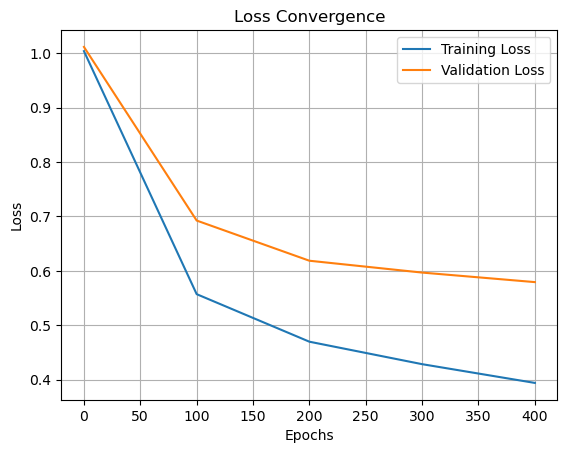

Training RMSE: 0.6417429592208397
Training R2: 0.5886823802830886
Test RMSE: 1.134174086283448
Test R2: -0.39218094255198355


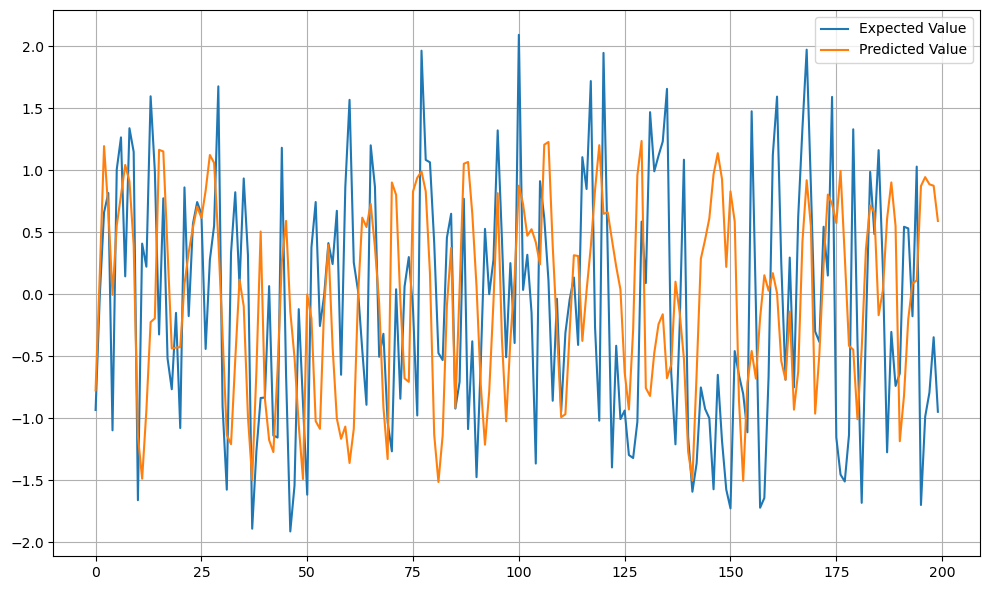

In [39]:
lookback = 10
test_steps = 5
target_col = 1
X_10_mv, y_10_mv, lenghts_10_mv, train_d_10_mv, test_d_10_mv = data_prep(samples,['MinTemp', 'MaxTemp', 'Rainfall', 
                                                                                  'WindGustSpeed','WindSpeed9am', 
                                                                                  'WindSpeed3pm', 'Humidity9am', 
                                                                                  'Humidity3pm','Pressure9am', 
                                                                                  'Pressure3pm', 'Temp9am', 
                                                                                  'Temp3pm'],
                                                                         lookback,test_steps, target_col)
print("Shape of input data after sequence creation:", X_10_mv.shape)
print("Shape of targets after sequence creation:", y_10_mv.shape)

num_features = X_10_mv.shape[2]
hidden_layer_size = 10
output_size = test_steps
n_epochs = 500
lr = 0.001
num_layers = 2
dropout_prob = 0.2
model_lstm_10_mv = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)

train_loss_history_10_mv,val_loss_history_10_mv, model_lstm_10_mv = train_predict_model(model_lstm_10_mv, n_epochs, 
                                                                                        lr, X_10_mv, y_10_mv, 
                                                                                        lenghts_10_mv,
                                                                                        validation_split=0.2)

vis_train_loss(train_loss_history_10_mv, val_loss_history_10_mv)

pred_eval(model_lstm_10_mv, X_10_mv, y_10_mv, lenghts_10_mv, train_d_10_mv, test_d_10_mv, lookback, target_col)

So far, we have explored how to build univariate and multivariate models with a fixed lookback. Now, let us see how to adapt the LSTM model to support a variable lookback.

To achieve that we need to make changes to the `create_sequences` function. For simplicity, let us consider a lookback value of `0` as variying lookback. If lookback is set to `0`, the function uses the full available history up to each time step, resulting in variable-length inputs, which are padded automatically using PyTorch's `pad_sequence` for batch processing. The function returns the padded input sequences, corresponding targets, and a list of sequence lengths for use with LSTM models.

In [42]:
import numpy as np
import torch
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence

def create_sequences(sequence, lookback, forecast_horizon, target_col, pad_value=0.0):
    T, num_features = sequence.shape
    X, y, lengths = [], [], []

    if lookback > 0:
        # Fixed-length lookback with pre-padding
        pad_vector = np.zeros((lookback, num_features))

        for t in range(1, T - forecast_horizon + 1):
            context = sequence[:t]
            if len(context) > lookback:
                context = context[-lookback:]

            padded_context = pad_vector.copy()
            padded_context[-len(context):] = context

            X.append(padded_context)
            y.append(sequence[t:t + forecast_horizon, target_col])
            lengths.append(min(len(context), lookback))

        return np.array(X), np.array(y), lengths

    else:
        # Full history with left pre-padding (variable-length inputs)
        for t in range(1, T - forecast_horizon + 1):
            context = torch.tensor(sequence[:t], dtype=torch.float32)
            lengths.append(t)

            X.append(context)  # No manual padding
            y.append(torch.tensor(sequence[t:t + forecast_horizon, target_col], dtype=torch.float32))

        X_padded = pad_sequence(X, batch_first=True, padding_value=pad_value)
        y_tensor = torch.stack(y)

        return X_padded.numpy(), y_tensor.numpy(), lengths

Shape of input data after sequence creation: torch.Size([2160, 54, 12])
Shape of targets after sequence creation: torch.Size([2160, 5])
The model has 1,895 trainable parameters
Epoch 1: train loss 1.0022, val loss 0.9832
Epoch 101: train loss 0.5278, val loss 0.5788
Epoch 201: train loss 0.4581, val loss 0.5281
Epoch 301: train loss 0.4008, val loss 0.4688
Epoch 401: train loss 0.3571, val loss 0.4259


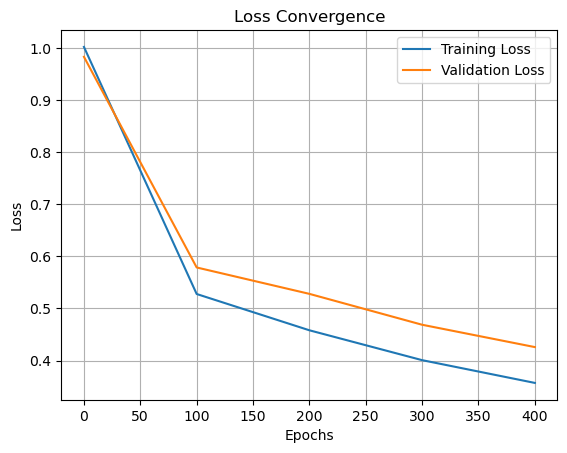

Training RMSE: 0.5870316292743192
Training R2: 0.6558259739775198
Test RMSE: 1.1100343099424415
Test R2: -0.3335492179536086


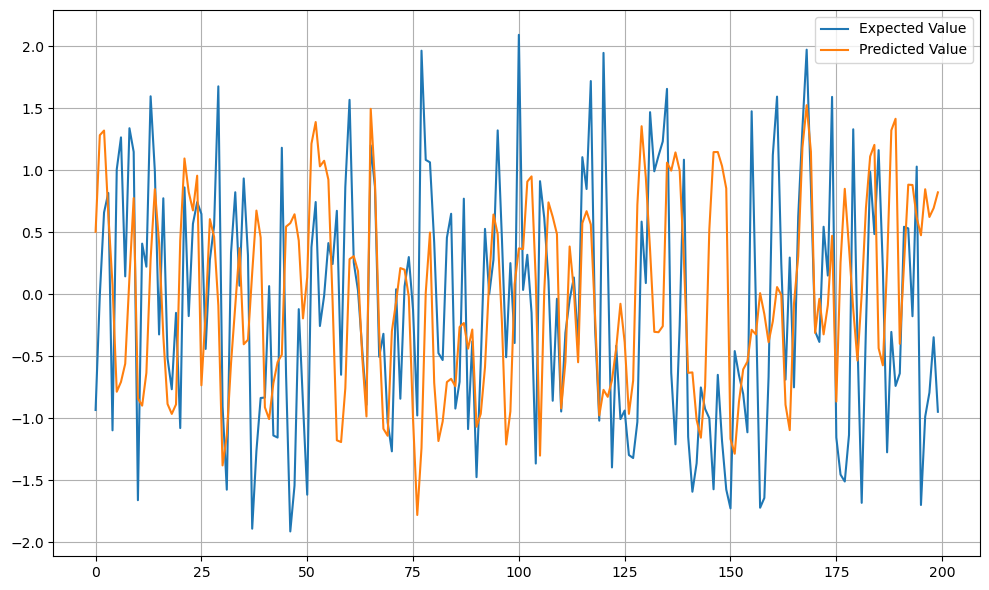

In [43]:
lookback = 0 # Means no restriction of lookback
target_col = 1
X_f, y_f,lengths_f, train_d_f, test_d_f = data_prep(samples,['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm'],lookback,test_steps, target_col)

print("Shape of input data after sequence creation:", X_f.shape)
print("Shape of targets after sequence creation:", y_f.shape)

num_features = X_f.shape[2]
hidden_layer_size = 10
output_size = test_steps
n_epochs = 500
lr = 0.001
num_layers = 2
dropout_prob = 0.2
model_lstm_f = MyLSTMNet(num_features, hidden_layer_size, num_layers, output_size,dropout_prob)

train_loss_history_f,val_loss_history_f,model_lstm_f = train_predict_model(model_lstm_f, n_epochs, 
                                                                           lr, X_f, y_f, lengths_f, 
                                                                           validation_split=0.2)

vis_train_loss(train_loss_history_f, val_loss_history_f)

pred_eval(model_lstm_f, X_f, y_f, lengths_f, train_d_f, test_d_f, lookback, target_col)

While some of the more extreme values are still mispredicted, we can see that the predicted temperatures are much closer to the actual values on unseen data. This shows that for this particular dataset, using multiple variables can provide a significant performance improvement.

One can also notice that the R-squared value is negative for the test dataset. This is quite common when a small number of test samples are considered, as in our case. Therefore, it is advisable not to rely heavily on the R-squared value and to focus more on RMSE or other similar metrics.

Other aspects that could potentially further improve performance, but are not included in this practical include:
- Using the categorical fields such as wind speed, by e.g. one-hot encoding them.
- Tuning the number of time points/sequence length used to make a prediction (we set it to 5 and 10).
- Tuning the batch size hyperparameter.
- Tuning the number of layers in the LSTM model.
- Tuning the size of the hidden layer in the LSTM model.
- Using additional hidden layers following the LSTM layer and creating a deeper network.

## End notes
---

In this practical, we learned how to build deep neural networks using the `Sequential` class in Pytorch, and compared the performance with a single hidden layer neural network. We found that on the Veteran dataset, using a deep network marginally improved the performance.

We also introduced recurrent neural networks by implementing a network that utilizes long short-term memory cells, or LSTMs. We implemented both univariate (single time dependent variable) and multivariate (multiple time dependent variables) models, and found that for the dataset we used and the weather forecasting application, multivariate was a significant impovement.

Finally, we introduced time series forecasting with both fixed and variable lookback windows.